### Imports

In [1]:
!pip install transformers

In [2]:
!pip install spacy_fastlang

In [3]:
import torch
from tqdm.notebook import tqdm

from torch.utils.data import TensorDataset
from google.colab import drive
import pandas as pd

import nltk
import re
nltk.download('wordnet')
nltk.download('stopwords')
from nltk.corpus import stopwords
from  nltk.stem import SnowballStemmer

import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib as mpl

from sklearn.model_selection import train_test_split
from sklearn.utils import compute_class_weight

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
from transformers import BertTokenizer

from transformers import BertForSequenceClassification
import numpy as np

In [5]:
import random

seed_val = 17
random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

### Load Data

In [6]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
path = '/content/drive/MyDrive/Memoria_Risk_Classification/Datos/'

df = pd.read_csv(path + 'TOSDR_SPLIT_DATA.csv')

In [8]:
print(df.head())
print(df.shape)

   Unnamed: 0    service                                       privacy_text  \
0           0  1password  The service does not guarantee that software e...   
1           1  1password  This service provides archives of their terms ...   
2           2  1password  The services will notify users if personal dat...   
3           3  1password  This service assumes no liability for any loss...   
4           4  1password  Users should revisit the terms periodically, a...   

                             case_link  label  \
0   https://edit.tosdr.org/points/6727      1   
1   https://edit.tosdr.org/points/6728      0   
2  https://edit.tosdr.org/points/13405      0   
3   https://edit.tosdr.org/points/6724      0   
4   https://edit.tosdr.org/points/6723      0   

                                                text idioma  clase data_type  
0  any errors or defects will be corrected  Terms...     en      1      test  
1  The Change Log section below is not a part of ...     en      0     t

In [9]:
df['label'].value_counts()

0    2861
1    1529
Name: label, dtype: int64

In [10]:
df['clase'] = df['label']

In [11]:
df.head()

,Unnamed: 0,service,privacy_text,case_link,label,text,idioma,clase,data_type
0,0,1password,The service does not guarantee that software e...,https://edit.tosdr.org/points/6727,1,any errors or defects will be corrected Terms...,en,1,test
1,1,1password,This service provides archives of their terms ...,https://edit.tosdr.org/points/6728,0,The Change Log section below is not a part of ...,en,0,train
2,2,1password,The services will notify users if personal dat...,https://edit.tosdr.org/points/13405,0,"In an event of a breach, we recognize our res...",en,0,test
3,3,1password,This service assumes no liability for any loss...,https://edit.tosdr.org/points/6724,0,"AgileBits, Inc., its directors, employees, par...",en,0,train
4,4,1password,"Users should revisit the terms periodically, a...",https://edit.tosdr.org/points/6723,0,"At our discretion, we may make changes to this...",en,0,train


In [12]:
df.groupby(['clase', 'data_type']).count()

Unnamed: 0  service  privacy_text  case_link  label  text  \
clase data_type                                                              
0     test              286      286           286        286    286   286   
      train            2317     2317          2317       2317   2317  2317   
      val               258      258           258        258    258   258   
1     test              153      153           153        153    153   153   
      train            1238     1238          1238       1238   1238  1238   
      val               138      138           138        138    138   138   

                 idioma  
clase data_type          
0     test          286  
      train        2317  
      val           258  
1     test          153  
      train        1238  
      val           138

### Clean Text

In [13]:
stop_words = stopwords.words("english")

stemmer = SnowballStemmer("english")

def clean_text(text):
  TEXT_CLEANING_RE = "@\S+|https?:\S+|http?:\S|[^A-Za-z0-9]+"
  TEXT_CLEANING_RE_EXTRA = "[^\w\s]"
  text = re.sub(TEXT_CLEANING_RE, ' ', str(text).lower()).strip()
  text = re.sub(TEXT_CLEANING_RE_EXTRA, ' ', str(text).lower()).strip()
  return text

def preprocess(text,cleaning=True,stopwords=True,stemming=True):
    if cleaning:
      text = clean_text(text)
    tokens = []
    for token in text.split():
        if (not stopwords) or (stopwords and (token not in stop_words)):
            if stemming:
                tokens.append(stemmer.stem(token))
            else:
                tokens.append(token)
    return " ".join(tokens)

In [14]:
# df['cleaned_text'] = df['text'].apply(lambda x: preprocess(x))

### Hiperparametros

In [15]:
DROPOUT = 0.1
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
EPSILON = 1e-8
EPOCH = 5


SEED = 17
NUM_LABELS = 2
# MODEL_NAME = "bert-base-uncased"
# MODEL_NAME = "roberta-base"
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128

### Prepare input for BERT

In [16]:
# tokenizer = BertTokenizer.from_pretrained(MODEL_NAME,
#                                           do_lower_case=True)

In [17]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def encode_data(df, set_name, MAX_LENGTH):
    encoded_data = tokenizer.batch_encode_plus(
        list(df[df.data_type==set_name].text.values),
        add_special_tokens=True,
        return_attention_mask=True,
        return_token_type_ids=True,
        pad_to_max_length=True,
        max_length=MAX_LENGTH,
        return_tensors='pt'
    )

    dataset = TensorDataset(encoded_data['input_ids'],
                            encoded_data['attention_mask'],
                            encoded_data['token_type_ids'],
                            torch.tensor(df[df.data_type==set_name].clase.values))

    return dataset

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:72: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [18]:
dataset_train = encode_data(df, 'train', MAX_LENGTH)
dataset_val = encode_data(df, 'val', MAX_LENGTH)
dataset_test = encode_data(df, 'test', MAX_LENGTH)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:2614: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(


In [19]:
len(dataset_train), len(dataset_val), len(dataset_test)

(3555, 396, 439)

In [20]:
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

dataloader_train = DataLoader(dataset_train,
                              sampler=RandomSampler(dataset_train),
                              batch_size=BATCH_SIZE)

dataloader_validation = DataLoader(dataset_val,
                                   sampler=SequentialSampler(dataset_val),
                                   batch_size=BATCH_SIZE)

dataloader_test = DataLoader(dataset_test,
                            sampler=SequentialSampler(dataset_test),
                            batch_size=BATCH_SIZE)

### Model Aquitecture

In [21]:
from transformers import AutoConfig
from transformers import AutoModelForSequenceClassification

configuration = AutoConfig.from_pretrained(MODEL_NAME)
configuration.num_labels = NUM_LABELS
configuration.output_attentions = False
configuration.output_hidden_states = False
configuration.classifier_dropout = DROPOUT

In [22]:
# model = BertForSequenceClassification.from_pretrained(MODEL_NAME,
#                                                       config = configuration)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME,
                                                      config = configuration)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier.bias', 'pre_classifier.weight', 'classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
# from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

# dataloader_train = DataLoader(dataset_train,
#                               sampler=RandomSampler(dataset_train),
#                               batch_size=BATCH_SIZE)

# dataloader_validation = DataLoader(dataset_val,
#                                    sampler=SequentialSampler(dataset_val),
#                                    batch_size=BATCH_SIZE)

# dataloader_test = DataLoader(dataset_test,
#                             sampler=SequentialSampler(dataset_test),
#                             batch_size=BATCH_SIZE)

In [24]:
# from transformers import AdamW, get_linear_schedule_with_warmup

# optimizer = AdamW(model.parameters(),
#                   lr=LEARNING_RATE,
#                   eps=EPSILON)

from transformers import AdamW, get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(),
                  betas=(0.9, 0.999),
                  lr=LEARNING_RATE,
                  eps=EPSILON)

scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps=0,
                                            num_training_steps=len(dataloader_train)*EPOCH)

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [25]:
from sklearn.metrics import f1_score, precision_recall_fscore_support

def metrics(preds, labels):
    preds_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return precision_recall_fscore_support(labels_flat, preds_flat, average='macro')

In [26]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(device)

cuda


In [27]:
pesos = compute_class_weight('balanced', classes = np.unique(df.label.values), y = df.label.values)
class_weights = {
    0: pesos[0],
    1: pesos[1]
}
class_weights = torch.tensor([pesos[0], pesos[1]], dtype=torch.float32).to(device)

In [28]:
# nSamples = df[df['data_type'] == 'train']['clase'].value_counts().sort_index().values
# class_weights = [1 - (x / sum(nSamples)) for x in nSamples]
# class_weights = torch.FloatTensor(class_weights).to(device)
# class_weights

In [29]:
# weights.view(-1)

### Entrenamiento

In [32]:
def evaluate(dataloader_val):

    model.eval()

    loss_val_total = 0
    predictions, true_vals = [], []

    for batch in dataloader_val:

        batch = tuple(b.to(device) for b in batch)

        inputs = {'input_ids':      batch[0],
                  'attention_mask': batch[1],
                  # 'token_type_ids': batch[2],
                  'labels':         batch[3]
                 }

        with torch.no_grad():
            outputs = model(**inputs)


        criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
        loss = criterion(outputs['logits'], inputs['labels'])


        # loss = outputs[0]
        # logits = outputs[1]
        logits = outputs['logits']
        loss_val_total += loss.item()

        logits = logits.detach().cpu().numpy()
        label_ids = inputs['labels'].cpu().numpy()
        predictions.append(logits)
        true_vals.append(label_ids)

    loss_val_avg = loss_val_total/len(dataloader_val)

    predictions = np.concatenate(predictions, axis=0)
    true_vals = np.concatenate(true_vals, axis=0)

    return loss_val_avg, predictions, true_vals

In [33]:
path_model = '/content/drive/MyDrive/Memoria_Group_Classification/Modelos/'

train_loss_history = []
val_loss_history = []
# early_stopper = EarlyStopper(patience=2, min_delta=10)

for epoch in tqdm(range(1, EPOCH+1)):

    model.train()

    loss_train_total = 0

    progress_bar = tqdm(dataloader_train, desc='Epoch {:1d}'.format(epoch), leave=False, disable=False)
    for batch in progress_bar:

        model.zero_grad()

        batch = tuple(b.to(device) for b in batch)

        inputs = {'input_ids':      batch[0],
                  'attention_mask': batch[1],
                  # 'token_type_ids': batch[2],
                  'labels':         batch[3]
                 }

        outputs = model(**inputs)

        criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
        loss = criterion(outputs['logits'], inputs['labels'])

        loss_train_total += loss.item()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        progress_bar.set_postfix({'training_loss': '{:.3f}'.format(loss.item()/len(batch))})

    torch.save(model.state_dict(), f'finetuned_V2_BERT_epoch_{epoch}.model')

    tqdm.write(f'\nEpoch {epoch}')

    loss_train_avg = loss_train_total/len(dataloader_train)
    tqdm.write(f'Training loss: {loss_train_avg}')

    val_loss, predictions, true_vals = evaluate(dataloader_validation)
    val_metrics = metrics(predictions, true_vals)

    train_loss_history.append(loss_train_avg)
    val_loss_history.append(val_loss)

    tqdm.write(f'Validation loss: {val_loss}')
    tqdm.write(f'Precision : {val_metrics[0]} - Recall : {val_metrics[1]} - F1 Score : {val_metrics[2]} (Validation)')

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/223 [00:00<?, ?it/s]


Epoch 1
Training loss: 0.564482415136735
Validation loss: 0.46931382179260256
Precision : 0.8181818181818181 - Recall : 0.8114256825075834 - F1 Score : 0.8145593869731801 (Validation)


Epoch 2:   0%|          | 0/223 [00:00<?, ?it/s]


Epoch 2
Training loss: 0.37263952105435555
Validation loss: 0.40888540625572206
Precision : 0.8671669503326629 - Recall : 0.8332490731378497 - F1 Score : 0.8460917964023553 (Validation)


...


Epoch 3
Training loss: 0.24070712332634647
Validation loss: 0.36807088494300844
Precision : 0.8713169642857144 - Recall : 0.873778227165487 - F1 Score : 0.8725191053382975 (Validation)


Epoch 4:   0%|          | 0/223 [00:00<?, ?it/s]


Epoch 4
Training loss: 0.1482341301923977
Validation loss: 0.4133385283499956
Precision : 0.8503251797045737 - Recall : 0.8736939669700033 - F1 Score : 0.8579886461286547 (Validation)


Epoch 5:   0%|          | 0/223 [00:00<?, ?it/s]


Epoch 5
Training loss: 0.09881566648242052
Validation loss: 0.4233874498307705
Precision : 0.8662473167948265 - Recall : 0.8785810583080553 - F1 Score : 0.8715838134336081 (Validation)


### Evaluation Metrics

In [34]:
def get_confusion_matrix(y_true, y_pred, class_names):
  fig, ax = plt.subplots(figsize=(6, 6))
  cm = confusion_matrix(y_true, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
  plt.rcParams.update({'font.size': 9})
  plt.rc('xtick', labelsize=9)
  plt.rc('ytick', labelsize=9)
  plt.xlabel('Predicted Label', fontsize=9)
  plt.ylabel('True Label', fontsize=9)
  disp = disp.plot(ax=ax,cmap=plt.cm.Greens, xticks_rotation='vertical')
  plt.show()

In [35]:
def plot_metrics(train_history, val_history, metrics = ['accuracy', 'F1']):

    plt.plot(train_history, color='blue', label='train')
    plt.plot(val_history,
             color='orange', label='val')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.ylim([0, plt.ylim()[1]])
    plt.legend();

In [36]:
_, predictions, true_vals = evaluate(dataloader_validation)
y_pred = predictions.argmax(axis=1)

In [37]:
labels_val = []
for _, _, _, labels in dataloader_validation:
    for x in labels:
        labels_val.append(x.item())

In [38]:
print(classification_report(labels_val, y_pred, target_names=['neutral','bad']))

              precision    recall  f1-score   support

     neutral       0.93      0.89      0.91       258
         bad       0.81      0.87      0.84       138

    accuracy                           0.88       396
   macro avg       0.87      0.88      0.87       396
weighted avg       0.88      0.88      0.88       396



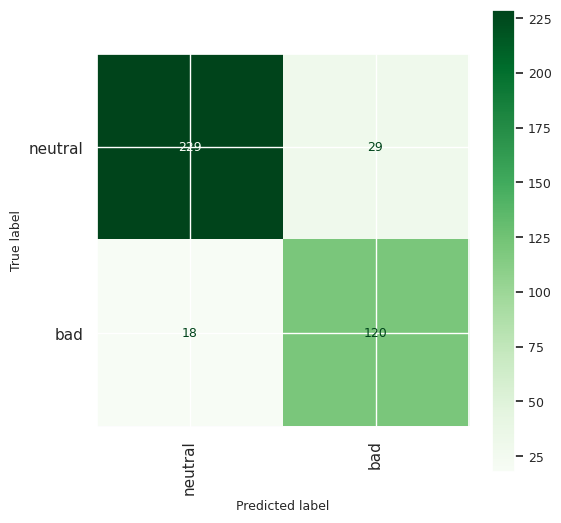

In [39]:
get_confusion_matrix(labels_val, y_pred, ['neutral','bad'])

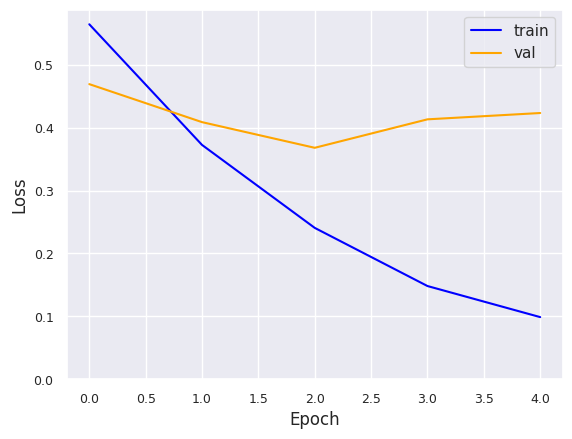

In [40]:
plot_metrics(train_loss_history, val_loss_history)

In [41]:
# model = BertForSequenceClassification.from_pretrained("bert-base-uncased",
#                                                       num_labels=2,
#                                                       output_attentions=False,
#                                                       output_hidden_states=False)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME,
                                                      config = configuration)

model.to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier.bias', 'pre_classifier.weight', 'classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
 

In [42]:
epoch = 3
model.load_state_dict(torch.load(f'finetuned_V2_BERT_epoch_{epoch}.model', map_location=torch.device('cuda')))

<All keys matched successfully>

In [43]:
_, predictions, true_vals = evaluate(dataloader_validation)
y_pred = predictions.argmax(axis=1)

In [44]:
print(classification_report(labels_val, y_pred, target_names=['neutral','bad']))

              precision    recall  f1-score   support

     neutral       0.91      0.91      0.91       258
         bad       0.83      0.84      0.83       138

    accuracy                           0.88       396
   macro avg       0.87      0.87      0.87       396
weighted avg       0.88      0.88      0.88       396



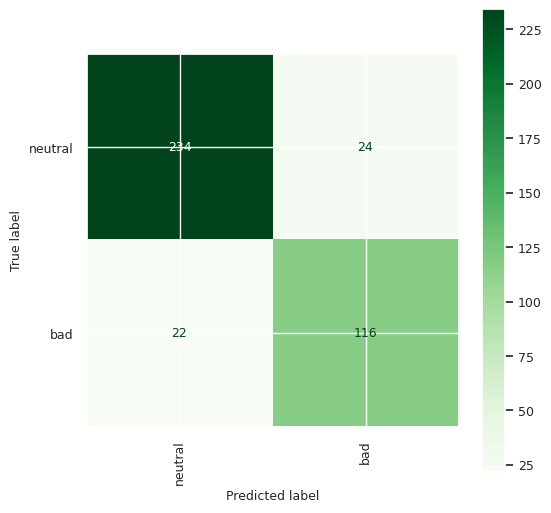

In [45]:
get_confusion_matrix(labels_val, y_pred, ['neutral','bad'])

In [ ]:
path = '/content/drive/MyDrive/Memoria_Risk_Classification/Modelos/'

torch.save(model.state_dict(), path + f'finetuned_V2_BERT_epoch_{epoch}_BEST_MODEL.model')